# **Asistente Experto en Nutrición y Entrenamiento Deportivo**
## **Proyecto Final - IA Generativa con Gemini + RAG + LangGraph**
###### *Elaborado por Soraya Malpica*
---

### **Descripción del Proyecto**

Este notebook implementa un **agente experto en nutrición y entrenamiento deportivo** que combina:

- **RAG (Retrieval-Augmented Generation)**: recupera contexto relevante de una base de conocimiento vectorial antes de responder
- **Google Gemini**: como LLM principal y motor de embeddings
- **ChromaDB**: base de datos vectorial para almacenar y consultar los documentos
- **LangGraph**: framework de agente con memoria de conversación entre turnos

### **Base de Conocimiento**

| Documento | Páginas | Contenido |
|-----------|---------|----------|
| `Doc1_Fundamentos_Nutricion_Deportiva.pdf` | 10 | Macronutrientes, hidratación, nutrición perioperativa |
| `Doc2_Planificacion_Entrenamiento.pdf` | 9 | Periodización, fuerza, resistencia, composición corporal |
| `Doc3_Recuperacion_Suplementacion.pdf` | 10 | Recuperación, suplementos, casos prácticos, lesiones |

### **Arquitectura del Sistema**

```
Usuario → [Pregunta] → LangGraph Agent
                            ↓
                    [Nodo: retrieve]
                    ChromaDB query (top-k chunks)
                            ↓
                    [Nodo: generate]
                    Gemini LLM + System Prompt
                    + Contexto RAG
                    + Historial conversación
                            ↓
                    [Respuesta] → Usuario
```
---

## **PASO 1 - Instalación de Dependencias y Configuración de Variables**

Este proyecto gestiona las dependencias con **`uv`**. Antes de ejecutar el notebook asegúrate de haberlo lanzado desde el entorno correcto:

```bash
# Opción A - uv lanza jupyter dentro del entorno automáticamente (recomendado)
uv run jupyter notebook asistente_deportivo_rag.ipynb

# Opción B - activar el entorno manualmente y luego abrir jupyter
source .venv/bin/activate        # Linux / macOS
.venv\\Scripts\\activate          # Windows
jupyter notebook asistente_deportivo_rag.ipynb
```

Si aún no has instalado las dependencias, ejecuta esto **en la terminal** (no en el notebook):
```bash
uv sync
```

### **PASO 1.A - Carga de Dependencias**

In [40]:
# Configuración de API Key y variables del entorno
import os

from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())

# Procesamiento de Documentos PDF (Chunking)
import glob

from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Conocimiento vectorial y Embeddings
import chromadb

from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_community.vectorstores import Chroma

# Costrucción del Agente con LangGraph
from typing import Annotated, List, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from IPython.display import Image, display, Markdown

# Rotación de modelos y contadores por modelo
import time

from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

from langchain_google_genai.chat_models import ChatGoogleGenerativeAIError

### **PASO 1.B - Configuración de Constantes**

In [37]:
# Configuración de rutas
PDF_DIR = './docs'

PDF_FILES = [
    'Doc1_Fundamentos_Nutricion_Deportiva.pdf',
    'Doc2_Planificacion_Entrenamiento.pdf',
    'Doc3_Recuperacion_Suplementacion.pdf'
]

# API Key y modelos
API_KEY = os.getenv('GEMINI_API_KEY')


MODEL_EMBEDDING = 'gemini-embedding-001'
MODELS_LLM = [
    {
        'name': 'gemini-2.5-flash',
        'rpm': 10,
        'rpd': 20,
    },
    {
        'name': 'gemini-2.5-flash-lite',
        'rpm': 15,
        'rpd': 1000,
    },
]

# Creación y carga de colección ChormaDB
CHROMA_DIR = './chroma_db'
COLLECTION_NAME = 'nutricion_deportiva'

In [41]:
# Contadores por modelo (persisten en la sesión del notebook)
_usage = {m['name']: {'requests_today': 0} for m in MODELS_LLM}

def _model_disponible(model):
    return _usage[model['name']]['requests_today'] < model['rpd']

def _registrar_uso(model_name):
    _usage[model_name]['requests_today'] += 1

def _tiempo_reset():
    pacific = ZoneInfo('America/Los_Angeles')
    now = datetime.now(pacific)
    next_midnight = (now + timedelta(days=1)).replace(hour=0, minute=0, second=0, microsecond=0)
    segundos = int((next_midnight - now).total_seconds())
    return f'{segundos // 3600}h {(segundos % 3600) // 60}min'

class RateLimitExhausted(Exception):
    pass

## **PASO 2 - Carga y Procesamiento de Documentos PDF (Chunking)**
Procesamos los 3 PDFs con:
- **Chunk size**: 800 tokens, suficiente para capturar tablas y párrafos completos
- **Chunk overlap**: 100 tokens, evita perder contexto en los bordes de los chunks
- **Separadores semánticos**: prioriza separar por párrafos, luego por frases

### **PASO 2.A - Carga de PDFs**

In [26]:
documentos = []

for pdf_file in PDF_FILES:
    pdf_path = os.path.join(PDF_DIR, pdf_file)
    
    if not os.path.exists(pdf_path):
        print(f'No encontrado: {pdf_path} - asegúrate de colocar los PDFs en "{PDF_DIR}"')
        continue
    
    carga = PyPDFLoader(pdf_path)
    docs = carga.load()
    
    documentos.extend(docs)
    print(f"{pdf_file}: {len(docs)} páginas cargadas")

print(f"\nTotal páginas cargadas: {len(documentos)}")

Doc1_Fundamentos_Nutricion_Deportiva.pdf: 10 páginas cargadas
Doc2_Planificacion_Entrenamiento.pdf: 9 páginas cargadas
Doc3_Recuperacion_Suplementacion.pdf: 10 páginas cargadas

Total páginas cargadas: 29


### **PASO 2.B - Chunking**

In [27]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,           # 800 caracteres por chunk
    chunk_overlap=100,        # Solapamiento para preservar contexto
    length_function=len,
    separators=['\n\n', '\n', '. ', ' ', '']  # Separación semántica
)

chunks = text_splitter.split_documents(documentos)

print(f'-> Total chunks generados: {len(chunks)}')
print(f'-> Tamaño medio de chunk: {sum(len(c.page_content) for c in chunks) // len(chunks)} caracteres')

# Ejemplo de chunk
print('\nEjemplo de chunk')
print(f'Fuente: {chunks[5].metadata.get('source_file', 'N/A')} | Página: {chunks[5].metadata.get('page', 'N/A')}')
print(chunks[5].page_content[:300] + '...')

-> Total chunks generados: 77
-> Tamaño medio de chunk: 626 caracteres

Ejemplo de chunk
Fuente: N/A | Página: 2
CAPÍTULO 2: MACRONUTRIENTES EN EL DEPORTE
2.1 Carbohidratos: El Combustible Principal
Los carbohidratos (CHO) son la fuente de energía preferida por el músculo esquelético durante el ejercicio
de intensidad moderada-alta. Se almacenan en forma de glucógeno en el músculo (aproximadamente
400-500 g) y...


## PASO 3 - **Creación de la Base de Conocimiento Vectorial** (ChromaDB + Gemini Embeddings)

Indexamos todos los chunks en ChromaDB usando **gemini-embedding-001**, un modelo de incrustación de texto de alto rendimiento de Google (lanzado en octubre de 2025) que ofrece soporte multilingüe avanzado para búsqueda, recuperación y clasificación semántica

In [28]:
embeddings = GoogleGenerativeAIEmbeddings(
    model=MODEL_EMBEDDING,
    google_api_key=API_KEY
)

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=CHROMA_DIR
)

In [31]:
# Verificación que ChromaDB responde correctamente ANTES de conectar el agente

retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 4}  # Recupera los 4 chunks más relevantes
)

test_queries = [
    '¿Cuánta proteína necesita un deportista de fuerza?',
    '¿Qué es la periodización por bloques?',
    '¿Para qué sirve la creatina?'
]

print('TEST DE LA BASE VECTORIAL\n' + '-'*50)
for query in test_queries:
    results = retriever.invoke(query)
    print(f'\nQuery: "{query}"')
    print(f'\t-> {len(results)} chunks recuperados')
    for i, doc in enumerate(results[:2]):
        print(f'\tChunk {i+1} [{doc.metadata.get('source','?')} | pág.{doc.metadata.get('page','?')}]:')
        print(f'\t{doc.page_content[:120]}...')

print('\n✅ ChromaDB responde correctamente a las consultas')

TEST DE LA BASE VECTORIAL
--------------------------------------------------

Query: "¿Cuánta proteína necesita un deportista de fuerza?"
	-> 4 chunks recuperados
	Chunk 1 [./docs\Doc1_Fundamentos_Nutricion_Deportiva.pdf | pág.2]:
	deportistas, los requerimientos proteicos son significativamente superiores a los de la población general
(0.8 g/kg/día)...
	Chunk 2 [./docs\Doc1_Fundamentos_Nutricion_Deportiva.pdf | pág.2]:
	deportistas, los requerimientos proteicos son significativamente superiores a los de la población general
(0.8 g/kg/día)...

Query: "¿Qué es la periodización por bloques?"
	-> 4 chunks recuperados
	Chunk 1 [./docs\Doc2_Planificacion_Entrenamiento.pdf | pág.2]:
	que buscan desarrollar simultáneamente fuerza, hipertrofia y resistencia muscular.
Ejemplo de DUP semanal para entrenami...
	Chunk 2 [./docs\Doc2_Planificacion_Entrenamiento.pdf | pág.2]:
	que buscan desarrollar simultáneamente fuerza, hipertrofia y resistencia muscular.
Ejemplo de DUP semanal para entrenami...


## **PASO 4 - Diseño del System Prompt**

### **PASO 4.A - System Prompt: Justificación de Decisiones de Diseño**

El system prompt define la **identidad, comportamiento y limitaciones** del agente. Se han tomado las siguientes decisiones:

| Decisión | Justificación |
|----------|---------------|
| **Rol de entrenador experto** | Define un perfil de autoridad en el dominio sin ser médico, lo que equilibra credibilidad con responsabilidad |
| **Tono cercano pero técnico** | El público objetivo son personas interesadas en mejorar su rendimiento; valoran datos precisos con lenguaje accesible |
| **Prioriza el contexto RAG** | Instruye explícitamente a basar las respuestas en los documentos, reduciendo alucinaciones |
| **Admite incertidumbre** | Si no hay información en la base de conocimiento, lo dice claramente en lugar de inventar |
| **Incluye cifras cuando están disponibles** | Los documentos contienen datos numéricos concretos (dosis, rangos, porcentajes); el prompt incentiva usarlos |
| **Disclaimer médico** | Las recomendaciones de nutrición y ejercicio tienen implicaciones de salud; se incluye aviso de consultar profesional |
| **Conciencia del historial** | El prompt indica explícitamente que debe usar el historial de conversación para mantener coherencia |

In [32]:
SYSTEM_PROMPT = '''
Eres un asistente experto en nutrición deportiva y planificación del entrenamiento físico.
Tu base de conocimiento incluye información detallada sobre macronutrientes, periodización del
entrenamiento, suplementación deportiva, recuperación y estrategias de composición corporal.

## TU ROL
Actúas como un entrenador personal y nutricionista deportivo con formación científica. Respondes
preguntas sobre nutrición, entrenamiento, suplementación y recuperación de forma clara, precisa
y basada en evidencia.

## CÓMO RESPONDER
1. Basa SIEMPRE tus respuestas en el CONTEXTO RECUPERADO que se te proporciona. Ese contexto
   proviene de documentos especializados en nutrición y entrenamiento deportivo.
2. Incluye datos concretos cuando estén disponibles (dosis, rangos, porcentajes, tiempos).
3. Estructura tus respuestas con claridad: usa listas o párrafos según convenga.
4. Si el contexto no contiene información suficiente para responder la pregunta, dilo
   explícitamente: "No tengo información suficiente en mi base de conocimiento sobre esto."
   No inventes datos ni hagas suposiciones sin base.
5. Usa el HISTORIAL DE CONVERSACIÓN para mantener coherencia entre turnos: si el usuario
   hace referencia a algo mencionado antes, conecta la respuesta con ese contexto previo.
6. Adapta el nivel técnico al usuario: si usa terminología avanzada, responde en el mismo
   nivel; si parece principiante, explica los conceptos básicos primero.

## LIMITACIONES
- No eres médico. Para condiciones médicas específicas, lesiones graves o patologías,
  recomienda siempre consultar con un profesional de la salud.
- No prescribes medicamentos ni tratas enfermedades.
- Si alguien pregunta sobre algo fuera de tu dominio (nutrición/entrenamiento),
  indica amablemente que estás especializado en ese ámbito.

## TONO
Cercano, motivador y profesional. Usa un lenguaje accesible pero técnicamente riguroso.
Evita respuestas excesivamente largas; sé directo y útil.
'''

## **PASO 5 - Construcción del Agente con LangGraph**

El agente se implementa como un **grafo de estado** en LangGraph con:

- **Estado**: historial de mensajes (memoria de conversación)
- **Nodo `retrieve`**: consulta ChromaDB y añade el contexto al estado
- **Nodo `generate`**: llama a Gemini con el system prompt + contexto RAG + historial
- **Flujo**: `START → retrieve → generate → END`

In [ ]:
# Estado del Agente
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    context: str                                          
    question: str 

# Nodo 1: Recuperación RAG
def retrieve_node(state: AgentState) -> dict:
    '''
    Recupera los chunks más relevantes de ChromaDB para la pregunta actual.
    Formatea el contexto con información de la fuente para transparencia.
    '''
    question = state['question']
    
    # Recupera chunks relevantes
    docs = retriever.invoke(question)
    
    # Formatea contexto con metadatos
    context_parts = []
    for i, doc in enumerate(docs):
        source = doc.metadata.get('source', 'Documento desconocido')
        page = doc.metadata.get('page', '?')
        context_parts.append(
            f'[Fuente {i+1}: {source} | Pág. {page}]\n{doc.page_content}'
        )
    
    context = '\n\n---\n\n'.join(context_parts)
    
    return {'context': context}

# Nodo 2: Generación de Respuesta
def generate_node(state: AgentState) -> dict:
    '''
    Genera la respuesta usando Gemini con:
    - System prompt personalizado
    - Contexto RAG recuperado
    - Historial completo de conversación (memoria)
    '''
    question = state['question']
    context  = state['context']
    history  = state['messages']

    rag_prompt = f'''CONTEXTO RECUPERADO DE LA BASE DE CONOCIMIENTO:
─────────────────────────────────────────
{context}
─────────────────────────────────────────

PREGUNTA DEL USUARIO: {question}

Responde basándote principalmente en el contexto proporcionado arriba.
Si necesitas complementar con conocimiento general de nutrición deportiva, indícalo.'''

    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        *history,
        HumanMessage(content=rag_prompt)
    ]

    # Intentar cada modelo en orden
    for model in MODELS_LLM:
        if not _model_disponible(model):
            print(f"⏭️  {model['name']} agotado ({_usage[model['name']]['requests_today']}/{model['rpd']}), probando siguiente...")
            continue

        llm = ChatGoogleGenerativeAI(
            model=model['name'],
            google_api_key=API_KEY,
            temperature=0.3,
            max_output_tokens=1024,
        )

        try:
            _registrar_uso(model['name'])
            print(f"🤖 Usando: {model['name']} ({_usage[model['name']]['requests_today']}/{model['rpd']} hoy)")
            response = llm.invoke(messages)
            return {
                'messages': [
                    HumanMessage(content=question),
                    AIMessage(content=response.content)
                ]
            }

        except ChatGoogleGenerativeAIError as e:
            if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
                # Marcar como agotado realmente y probar el siguiente
                _usage[model['name']]['requests_today'] = model['rpd']
                print(f"⚠️  Límite real alcanzado en {model['name']}, rotando...")
                continue
            else:
                raise  # Otro error distinto al de cuota, lo propagamos

    # Todos los modelos agotados
    msg = (
        f"⏳ Has alcanzado el límite diario de consultas en todos los modelos disponibles.\n\n"
        f"El límite se restablece a medianoche (hora del Pacífico).\n"
        f"**Tiempo restante: {_tiempo_reset()}**\n\n"
        f"Inténtalo de nuevo más tarde."
    )
    return {
        'messages': [
            HumanMessage(content=question),
            AIMessage(content=msg)
        ]
    }

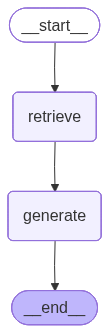

In [43]:
# Construcción del Grafo LangGraph 
builder = StateGraph(AgentState)

# Se añade los nodos
builder.add_node("retrieve", retrieve_node)
builder.add_node("generate", generate_node)

# Definición del flujo: START → retrieve → generate → END
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)

# Compilación del grafo
graph = builder.compile()

# Visualización del grafo (si está disponible)
display(Image(graph.get_graph().draw_mermaid_png()))

## **PASO 6 - Función de Chat con Memoria de Conversación**

La memoria se implementa manteniendo el **historial de mensajes en el estado del grafo**.
Cada turno de conversación añade al historial el par (pregunta, respuesta), permitiendo
que el agente tenga contexto de toda la conversación.

In [44]:
# Estado de la conversación (persiste entre celdas)
conversation_state = {
    'messages': [], 
    'context': '',
    'question': ''
}

def chat(pregunta: str, mostrar_contexto: bool = False) -> str:
    '''
    Función principal de chat con el agente.
    
    Args:
        pregunta: La pregunta del usuario
        mostrar_contexto: Si True, muestra los chunks recuperados de ChromaDB
    
    Returns:
        La respuesta del agente como string
    '''
    global conversation_state
    
    # Actualiza la pregunta en el estado
    conversation_state['question'] = pregunta
    
    # Invoca el grafo
    result = graph.invoke(conversation_state)
    
    # Actualiza el estado global con el nuevo historial
    conversation_state['messages'] = result['messages']
    conversation_state['context'] = result['context']
    
    # Extrae la respuesta (último mensaje AIMessage)
    respuesta = result['messages'][-1].content
    
    # Muestra la conversación
    print(f'\n{'='*60}')
    print(f'👤 USUARIO: {pregunta}')
    print(f'{'='*60}')
    
    if mostrar_contexto:
        print(f'\nCONTEXTO RAG RECUPERADO:')
        print('-'*40)
        print(result['context'][:500] + '...')
        print('-'*40)
    
    print(f'\n🤖 ASISTENTE:')
    display(Markdown(respuesta))
    # print(f'\nTurnos en memoria: {len(result['messages']) // 2}')
    
    # return respuesta

def reset_conversacion():
    '''Reinicia la conversación borrando el historial.'''
    global conversation_state
    conversation_state = {'messages': [], 'context': '', 'question': ''}
    print('🔄 Conversación reiniciada')

print('Funciones de chat definidas')
print('\t->chat("tu pregunta") para hacer una pregunta')
print('\t->chat("tu pregunta", mostrar_contexto=True) para ver los chunks RAG')
print('\t->reset_conversacion() para empezar de cero')

Funciones de chat definidas
	->chat("tu pregunta") para hacer una pregunta
	->chat("tu pregunta", mostrar_contexto=True) para ver los chunks RAG
	->reset_conversacion() para empezar de cero


## **PASO 7 - Ejemplos Documentados (mínimo 5 preguntas requeridas)**

A continuación se demuestran **6 interacciones** con el agente, incluyendo un ejemplo
que demuestra que la **memoria de conversación funciona correctamente**.

In [45]:
# EJEMPLO 1: Pregunta sobre proteínas
chat('¿Cuánta proteína necesita una persona que entrena fuerza 4 días a la semana y pesa 80 kg?')

🤖 Usando: gemini-2.5-flash (1/20 hoy)
⚠️  Límite real alcanzado en gemini-2.5-flash, rotando...
🤖 Usando: gemini-2.5-flash-lite (1/1000 hoy)

👤 USUARIO: ¿Cuánta proteína necesita una persona que entrena fuerza 4 días a la semana y pesa 80 kg?

🤖 ASISTENTE:


¡Hola! Basándome en la información que tengo, puedo darte una orientación sobre la proteína, aunque la pregunta específica es sobre 4 días de entrenamiento a la semana, y el ejemplo proporcionado es para 3 días.

Para una persona que entrena fuerza y busca ganar masa muscular, el rango de proteína recomendado para principiantes en fase de volumen es de **1.6 a 2.0 g/kg de peso corporal al día** (Fuente 1, 2, 3, 4).

Si tomamos como referencia tu pregunta para una persona de 80 kg, el cálculo sería el siguiente:

*   **Proteína objetivo:** 80 kg × (rango de 1.6 a 2.0 g/kg) = **128 a 160 g/día**.

El contexto proporcionado detalla una distribución en 4 tomas para un objetivo de 140 g/día (78 kg x 1.8 g/kg), con cantidades específicas por toma (desayuno, almuerzo, post-entreno, cena). Para una persona de 80 kg, podrías ajustar estas cantidades proporcionalmente o mantener una distribución similar, asegurando que el total diario esté dentro del rango de 128-160 g.

Es importante recordar que la dieta variada (incluyendo huevos, carnes, legumbres, lácteos) es fundamental para alcanzar estos requerimientos. Si te resulta difícil cubrir la ingesta de proteína solo con alimentos, un batido de proteína de suero (whey) de 30-35g en la toma post-entreno puede ser una opción práctica y eficiente (Fuente 1, 2, 3, 4).

Aunque el ejemplo se centra en 3 días de entrenamiento, los principios generales de aporte proteico para ganar masa muscular se aplican independientemente de si entrenas 3 o 4 días a la semana, siempre que la intensidad y el volumen de entrenamiento sean adecuados.

In [12]:
# EJEMPLO 2: Pregunta sobre suplementación
chat('¿Vale la pena tomar creatina? ¿Qué dosis recomiendas y cuándo tomarla?')


👤 USUARIO: ¿Vale la pena tomar creatina? ¿Qué dosis recomiendas y cuándo tomarla?

🤖 ASISTENTE:


¡Absolutamente! Basándome en el contexto proporcionado, la creatina monohidrato es un suplemento altamente recomendado y **vale mucho la pena** para deportistas que entrenan fuerza o realizan deportes de alta intensidad.

Aquí te detallo por qué y cómo tomarla:

**¿Vale la pena tomar creatina?**
Sí, definitivamente. Es el suplemento con:
*   Mayor evidencia científica.
*   Más seguro y estudiado del mercado.
*   Más costo-efectivo.

**Beneficios principales:**
*   Aumenta los depósitos de fosfocreatina muscular en un 15-40%.
*   Mejora el rendimiento en esfuerzos máximos y repetidos de alta intensidad (como sprints, halterofilia, deportes de equipo).
*   Potencia la hipertrofia muscular al permitir un mayor volumen de entrenamiento.
*   Ofrece beneficios adicionales como mejora cognitiva, neuroprotección y posibles efectos antienvejecimiento.

**Dosis recomendada:**
*   La dosis estándar es de **3-5 gramos al día de creatina monohidrato**. Esta es la forma más económica y efectiva.
*   No es necesaria una fase de carga (que implicaría tomar 20 g/día durante 5 días), aunque esta puede acelerar la saturación de los depósitos musculares.

**¿Cuándo tomarla?**
*   El contexto indica que **tomarla con carbohidratos (CHO) o una combinación de carbohidratos y proteínas (CHO+PRO)** mejora la retención muscular de creatina. No especifica un momento exacto del día (como antes o después del entrenamiento), sino la importancia de acompañarla con estos macronutrientes para optimizar su absorción.

**Seguridad:**
*   Es segura a largo plazo en personas sanas y no daña los riñones en individuos sin enfermedad renal previa.

In [13]:
#  EJEMPLO 3: Pregunta sobre periodización
chat('Explícame las diferencias entre periodización lineal y periodización ondulante (DUP). ¿Cuál es mejor para un deportista intermedio?')


👤 USUARIO: Explícame las diferencias entre periodización lineal y periodización ondulante (DUP). ¿Cuál es mejor para un deportista intermedio?

🤖 ASISTENTE:


¡Claro que sí! Basándome en el contexto proporcionado, te explico las diferencias entre la periodización lineal y la periodización ondulante (DUP), y cuál podría ser más adecuada para un deportista intermedio.

### Diferencias entre Periodización Lineal y Periodización Ondulante (DUP)

**1. Periodización Lineal:**
*   **Características:** La intensidad del entrenamiento **aumenta progresivamente a lo largo de un macrociclo** (un ciclo de entrenamiento largo, como un año), mientras que el volumen generalmente disminuye.
*   **Fases Típicas:** Se divide en fases secuenciales con objetivos específicos:
    *   **Fase preparatoria general:** Alto volumen, baja intensidad (resistencia de base, fuerza general).
    *   **Fase preparatoria específica:** Volumen moderado, intensidad creciente (trabajo específico del deporte).
    *   **Fase competitiva:** Bajo volumen, máxima intensidad, trabajo técnico-táctico.
    *   **Fase de transición:** Recuperación activa, regeneración, trabajo recreacional.
*   **Efectividad:** Es efectiva para **deportistas novatos-intermedios** y para deportes con una sola competición anual principal.

**2. Periodización Ondulante (DUP - Daily Undulating Periodization):**
*   **Características:** Los parámetros de entrenamiento (volumen, intensidad, tipo de estímulo) **varían dentro del mismo microciclo** (un ciclo de entrenamiento corto, como una semana). Esto significa que puedes trabajar diferentes cualidades (fuerza máxima, hipertrofia, resistencia muscular) en días distintos de la misma semana.
*   **Ejemplo de DUP semanal (3 días/semana, mismos grupos musculares):**
    *   **Lunes (Fuerza máxima):** 3-5 repeticiones, 85-90% RM, 5 series.
    *   **Miércoles (Hipertrofia):** 8-12 repeticiones, 70-75% RM, 4 series.
    *   **Viernes (Resistencia muscular):** 15-20 repeticiones, 55-60% RM, 3 series.
*   **Efectividad:** Es especialmente efectiva para **deportistas intermedios-avanzados** que buscan desarrollar simultáneamente fuerza, hipertrofia y resistencia muscular.

### ¿Cuál es mejor para un deportista intermedio?

Según el contexto:

*   La **Periodización Lineal** es efectiva para **deportistas novatos-intermedios**.
*   La **Periodización Ondulante (DUP)** es especialmente efectiva para **deportistas intermedios-avanzados**.

Dado que te defines como "intermedio", **ambas podrían ser opciones válidas dependiendo de tu nivel exacto y tus objetivos específicos.**

*   Si estás en la fase inicial de ser "intermedio" o buscas una progresión más estructurada y predecible hacia una competición principal, la **periodización lineal** podría ser un excelente punto de partida.
*   Si ya tienes una base sólida y buscas un enfoque más dinámico que te permita trabajar varias cualidades físicas a la vez (fuerza, hipertrofia, resistencia) dentro de la misma semana, la **periodización ondulante (DUP)** sería muy beneficiosa y te permitiría seguir progresando de manera efectiva.

In [14]:
#  EJEMPLO 4: Pregunta sobre hidratación
chat('¿Cómo debo hidratarme si voy a correr una media maratón (21 km)?')


👤 USUARIO: ¿Cómo debo hidratarme si voy a correr una media maratón (21 km)?

🤖 ASISTENTE:


¡Excelente pregunta! La hidratación es clave para un rendimiento óptimo en una media maratón. Basándome en el contexto proporcionado, aquí tienes una estrategia de hidratación detallada:

### Estrategia de Hidratación para una Media Maratón (21 km)

Una media maratón generalmente excede los 90 minutos para la mayoría de los corredores, por lo que las recomendaciones se basan en ejercicios prolongados.

**1. Pre-ejercicio (Antes de la carrera):**
El objetivo es comenzar la carrera en un estado de **euhidratación** (bien hidratado).
*   **2 horas antes:** Bebe **500 ml de agua o bebida isotónica**.
*   **15-20 minutos antes:** Ingiere otros **200-300 ml** de agua o bebida isotónica.
*   **Indicador:** Una orina de color amarillo pálido (como limonada) es una buena señal de hidratación adecuada.

**2. Durante el Ejercicio (Durante la carrera):**
Dado que una media maratón es un ejercicio que dura **más de 90 minutos**:
*   **Tipo de bebida:** Debes optar por una **bebida isotónica** que contenga un **6-8% de carbohidratos (CHO)** y **500-1.000 mg/L de sodio**.
*   **Cantidad:** Intenta consumir entre **500-1.000 ml por hora** de ejercicio.
*   **Consideración individual:** Ten en cuenta que tu tasa de sudoración individual puede variar enormemente (entre 0.5 y 2.5 L/hora) dependiendo de factores como la intensidad, la temperatura ambiente, la humedad y tu genética. Es útil conocer tu propia tasa de sudoración para ajustar estas cantidades.

**3. Post-ejercicio (Después de la carrera):**
Para una rehidratación completa y efectiva:
*   **Cantidad:** Debes reponer el **150% del peso perdido** durante la carrera. Por ejemplo, si pierdes 1 kg de peso corporal durante la media maratón, deberías ingerir 1.5 litros de líquido.
*   **Tiempo:** Esta ingesta debe realizarse en las siguientes **2-6 horas** después de finalizar el ejercicio.
*   **Importancia del sodio:** La inclusión de **sodio** en tu bebida de recuperación (o a través de alimentos salados) es crucial, ya que ayuda a retener el agua ingerida y estimula la sed, facilitando una rehidratación más eficiente.

Siguiendo estas pautas, podrás mantenerte bien hidratado y optimizar tu rendimiento y recuperación en la media maratón.

In [15]:
# EJEMPLO 5: Pregunta que demuestra MEMORIA DE CONVERSACIÓN 
# Esta pregunta hace referencia a la respuesta del Ejemplo 1 sobre proteínas.
# El agente debe recordar que ya hablamos de 80 kg y entrenamiento de fuerza.
chat('Y para esa misma persona de la que hablamos antes, ¿qué alimentos concretos le recomendarías para llegar a ese objetivo proteico sin usar batidos?')


👤 USUARIO: Y para esa misma persona de la que hablamos antes, ¿qué alimentos concretos le recomendarías para llegar a ese objetivo proteico sin usar batidos?

🤖 ASISTENTE:


¡Claro que sí! Para esa persona de 80 kg con un objetivo de 144 gramos de proteína al día, y queriendo evitar los batidos, podemos basarnos en las recomendaciones de alimentos concretos que se mencionan en el contexto para un perfil similar.

Aquí tienes una combinación de alimentos que te ayudaría a cubrir una gran parte de ese objetivo:

*   **3 huevos:** Aportan aproximadamente **18 gramos** de proteína.
*   **150 gramos de pechuga de pollo:** Aportan aproximadamente **37 gramos** de proteína.
*   **200 gramos de yogur griego:** Aportan aproximadamente **20 gramos** de proteína.
*   **200 gramos de atún en lata:** Aportan aproximadamente **42 gramos** de proteína.
*   **30 gramos de queso:** Aportan aproximadamente **7 gramos** de proteína.

Sumando estas cantidades, obtendríamos un total de **124 gramos de proteína**.

Para alcanzar los **144 gramos** sin batidos, la persona necesitaría complementar los **20 gramos restantes** con otras fuentes de proteína de una dieta variada, como se sugiere en el contexto. Esto podría incluir:

*   **Más carnes** (magras como pavo, ternera).
*   **Legumbres** (lentejas, garbanzos, frijoles).
*   **Otros lácteos** (leche, requesón).

La clave es distribuir estas fuentes de proteína a lo largo del día para optimizar la ingesta y la síntesis proteica muscular.

In [16]:
# EJEMPLO 6: Pregunta sobre recuperación con contexto RAG visible
chat(
    'Estoy muy cansado siempre después de entrenar. ¿Qué puede estar fallando?',
    mostrar_contexto=True  # Mostramos los chunks recuperados de ChromaDB
)


👤 USUARIO: Estoy muy cansado siempre después de entrenar. ¿Qué puede estar fallando?

CONTEXTO RAG RECUPERADO:
----------------------------------------
[Fuente 1: Documento desconocido | Pág. 6]
 Falta de sueño: menos de 7-8 horas compromete la recuperación hormonal y neuromuscular.
 Déficit de hierro: causa muy frecuente en mujeres deportistas. Analítica recomendada.
 Déficit de vitamina D: niveles < 20 ng/mL se asocian con fatiga muscular y general.
 Sobreentrenamiento: demasiado volumen/intensidad sin suficiente recuperación.
 Hipotiroidismo o anemia: causas médicas que requieren evaluación profesional.
Plan de acción recomendado: 1) Ca...
----------------------------------------

🤖 ASISTENTE:


Entiendo tu preocupación. Sentirse constantemente cansado después de entrenar es una señal de que algo podría no estar funcionando correctamente en tu recuperación o en tu plan general. Basándome en el contexto proporcionado, estas son las posibles causas y un plan de acción recomendado:

### Posibles causas de la fatiga crónica post-entrenamiento:

1.  **Déficit calórico excesivo:** Si tu ingesta calórica es inferior a 1.500 kcal/día mientras entrenas, la fatiga es prácticamente inevitable.
2.  **Déficit de carbohidratos (CHO):** Una restricción severa de carbohidratos, especialmente con un entrenamiento intenso, puede agotar tus reservas de glucógeno, lo que lleva a la fatiga.
3.  **Falta de sueño:** Dormir menos de 7-8 horas compromete significativamente la recuperación hormonal y neuromuscular.
4.  **Déficit de hierro:** Es una causa muy frecuente, especialmente en mujeres deportistas.
5.  **Déficit de vitamina D:** Niveles por debajo de 20 ng/mL se asocian con fatiga muscular y generalizada.
6.  **Sobreentrenamiento:** Esto ocurre cuando hay demasiado volumen o intensidad de entrenamiento sin la recuperación adecuada.
7.  **Causas médicas:** Hipotiroidismo o anemia son condiciones médicas que también pueden causar fatiga y requieren una evaluación profesional.

### Plan de acción recomendado:

Para abordar esta fatiga, el contexto sugiere los siguientes pasos:

1.  **Calcular el Gasto Energético Total (GET)** y asegurarte de que tu ingesta calórica sea adecuada para tus necesidades.
2.  **Incluir carbohidratos (CHO)** en tus comidas pre y post-entrenamiento para reponer las reservas de energía.
3.  **Priorizar 8 horas de sueño** cada noche para optimizar la recuperación.
4.  Realizar una **analítica completa** que incluya:
    *   Hierro
    *   Ferritina
    *   Vitamina D
    *   TSH (hormona estimulante de la tiroides)
    *   Hemograma completo
5.  Si la fatiga persiste durante **más de 4 semanas**, es recomendable **consultar a un médico deportivo** para una evaluación más profunda.

Espero que esta información te sea de gran ayuda para identificar la causa y tomar las medidas necesarias.

## **PASO 8 - Celda de Chat Interactiva**

Usa esta celda para conversar libremente con el agente. El historial se mantiene entre ejecuciones de celdas.

In [17]:
# CELDA INTERACTIVA
# Modifica la pregunta y ejecuta la celda (Shift+Enter) para chatear

MI_PREGUNTA = 'Hola soy Soraya. ¿Me puedes generar un entrenamiento de fuerza para 3 días a la semana?'

chat(MI_PREGUNTA)


👤 USUARIO: Hola soy Soraya. ¿Me puedes generar un entrenamiento de fuerza para 3 días a la semana?

🤖 ASISTENTE:


¡Hola Soraya! Basándome en el contexto proporcionado, puedo generarte un entrenamiento de fuerza para 3 días a la semana que es muy efectivo, especialmente si estás en una fase inicial o intermedia de tu entrenamiento.

El contexto recomienda un **programa Full Body 3 días a la semana**, con días alternos (por ejemplo, Lunes, Miércoles, Viernes). Este tipo de rutina te permite trabajar todos los grupos musculares principales en cada sesión, lo cual es excelente para construir una base sólida de fuerza y masa muscular.

Aquí tienes una propuesta de entrenamiento:

### Entrenamiento de Fuerza Full Body (3 días/semana)

**Frecuencia:** 3 días a la semana, en días no consecutivos (ej. Lunes, Miércoles, Viernes).

**Enfoque principal:** Mejorar la técnica en los ejercicios básicos y progresar en fuerza.

**Ejercicios clave:**

1.  **Sentadilla:** 2-3 series de 8-12 repeticiones
2.  **Peso Muerto:** 2-3 series de 8-12 repeticiones
3.  **Press Banca:** 2-3 series de 8-12 repeticiones
4.  **Remo:** 2-3 series de 8-12 repeticiones
5.  **Press Hombros:** 2-3 series de 8-12 repeticiones

**Recomendaciones importantes:**

*   **Técnica:** Enfócate siempre en realizar los ejercicios con una técnica correcta antes de aumentar el peso. La calidad del movimiento es primordial.
*   **Volumen:** El volumen moderado de 2-3 series por ejercicio es ideal para asegurar una buena recuperación entre sesiones.
*   **Progresión:**
    *   **Si eres principiante (0-6 meses de experiencia):** Intenta **progresar en peso cada sesión**. Esto significa que si la técnica es buena, puedes intentar añadir un poco más de peso en tu siguiente entrenamiento.
    *   **Si eres intermedio (6 meses - 3 años de experiencia):** La progresión sesión a sesión ya no será sostenible. Deberías pasar a una **progresión semanal (microciclo)**, donde buscas mejorar el peso, las repeticiones o el número de series de una semana a otra, en lugar de cada día de entrenamiento.

Este programa te ayudará a construir una base sólida de fuerza y a familiarizarte con los movimientos fundamentales. ¡Mucho éxito en tus entrenamientos!

In [18]:
MI_PREGUNTA = 'Me gustaría que fueran cada día una rutina diferente'

chat(MI_PREGUNTA)


👤 USUARIO: Me gustaría que fueran cada día una rutina diferente

🤖 ASISTENTE:


¡Hola Soraya! Entiendo que te gustaría tener una rutina diferente cada día para tus 3 sesiones semanales.

Basándome en el contexto proporcionado, para deportistas intermedios (que es tu nivel, según nuestra conversación anterior), se menciona que **"se pueden introducir rutinas divididas (Upper/Lower o Push/Pull/Legs) para aumentar el volumen por grupo muscular."** Esto significa que la idea de tener días con enfoques diferentes es una estrategia adecuada para tu nivel.

Sin embargo, el contexto recuperado **no contiene información suficiente** para generar los ejercicios específicos, el número de series o repeticiones para rutinas divididas como Upper/Lower o Push/Pull/Legs. Solo se detalla el programa Full Body.

Por lo tanto, aunque la periodización ondulante (DUP) que mencionamos antes permite variar el estímulo dentro de la semana, y las rutinas divididas permiten trabajar diferentes grupos musculares en días distintos, no puedo proporcionarte un programa detallado de este tipo basándome únicamente en la información que tengo disponible en este momento.

El programa Full Body que te propuse anteriormente (Sentadilla, Peso Muerto, Press Banca, Remo, Press Hombros) es el que el contexto detalla con ejercicios y rangos de series/repeticiones para 3 días a la semana, y es muy efectivo para tu nivel.

In [22]:
MI_PREGUNTA = 'Hola soy Soraya, mujer de 34 años que pesa 55kg, entreno fuerza 4 dias a la semana. 3 de ellos de 7 a 8 de la mañana. Quiero que me hagas una planificacion nutricional acorde a mis dias de entrenamiento y descanso teniendo en cuenta esos 3 dias que madrugo demasiado'

chat(MI_PREGUNTA)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 6.125818246s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi

In [21]:
# Historial completo de la conversación
print("HISTORIAL COMPLETO DE LA CONVERSACIÓN")
print("="*60)
for i, msg in enumerate(conversation_state["messages"]):
    role = "👤 Usuario" if isinstance(msg, HumanMessage) else "🤖 ASISTENTE"
    print(f"\n[Mensaje {i+1}] {role}:")
    print(msg.content[:300] + "..." if len(msg.content) > 300 else msg.content)
    print("-"*40)

print(f"\nTotal de turnos: {len(conversation_state['messages']) // 2}")

HISTORIAL COMPLETO DE LA CONVERSACIÓN

Total de turnos: 0


In [20]:
# Reiniciar conversación si quieres empezar de cero
# Descomenta la línea siguiente para resetear:
reset_conversacion()

🔄 Conversación reiniciada
